In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
# import kaggle
# import zipfile
from IPython.display import Markdown

from pycaret.clustering import setup, create_model, plot_model, pull, assign_model, assign_model
# from pycaret.datasets import get_data

# 1 Analysis objectives:

1. Use clustering to identify patterns of customer behavior.
2. Check whether the data contains characteristic groups of transactions related to purchase time and price level.
3. Identify key sales hours and recurring purchasing patterns.

Use clustering to detect patterns of customer behavior, identify key sales hours, and check whether transactions can be divided into meaningful groups according to purchase time and price level.

#### EDA of the dataset was conducted earlier at:
https://krzysztofzakrzewski.github.io/portfolio/coffee/

#### Original dataset:
https://www.kaggle.com/datasets/navjotkaushal/coffee-sales-dataset

#### Dataset author:
https://www.kaggle.com/navjotkaushal


#### Dataset appearance after adding the 'Evenig' category to the 'Time_of_Day' column.

In [7]:
coffee_df = pd.read_csv('data/Coffe_sales_ML.csv')
coffee_df.head(5)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,Date Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50,2024-03-01 10:15:50
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22,2024-03-01 12:19:22
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18,2024-03-01 12:20:18
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33,2024-03-01 13:46:33
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14,2024-03-01 13:48:14


#### Removal of the 'cash_type' column, which does not add any value due to its 100% homogeneity.

In [8]:
cluster_coffee_df = coffee_df.drop(columns=['cash_type'])
# cluster_coffee_df.head(5)

#### Dataframe info

In [9]:
cluster_coffee_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   money        3547 non-null   float64
 2   coffee_name  3547 non-null   object 
 3   Time_of_Day  3547 non-null   object 
 4   Weekday      3547 non-null   object 
 5   Month_name   3547 non-null   object 
 6   Weekdaysort  3547 non-null   int64  
 7   Monthsort    3547 non-null   int64  
 8   Date         3547 non-null   object 
 9   Time         3547 non-null   object 
 10  Date Time    3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


## 2. Operations on the dataset

## To enable the analysis of customer behavior, appropriate operations were applied:

### 2.1 Time data processing

1. The Date and Time columns were combined into a single datetime variable. Then, the data was simplified by removing microseconds, which did not provide significant analytical value.
2. After creating the datetime variable, the original columns were removed as redundant.
3. Based on the time variable, new features were extracted:

hour – transaction hour,
weekday – day of the week (0 = Monday).

These features enabled the analysis of purchasing patterns depending on the time of day and the day of the week, which formed the basis for further clustering analysis.

In [10]:
cluster_coffee_df["datetime"] = pd.to_datetime(
    cluster_coffee_df["Date"] + " " + cluster_coffee_df["Time"],
    format="mixed"
)
cluster_coffee_df["datetime"] = cluster_coffee_df["datetime"].dt.floor("s")
cluster_coffee_df.drop(columns=["Date", "Time"], inplace=True)
cluster_coffee_df["hour"] = cluster_coffee_df["datetime"].dt.hour
cluster_coffee_df["weekday"] = cluster_coffee_df["datetime"].dt.weekday

In [11]:
# (cluster_coffee_df["hour_of_day"] != cluster_coffee_df["datetime"].dt.hour).sum()

In [12]:
# cluster_coffee_df[
#     cluster_coffee_df["hour_of_day"] != cluster_coffee_df["datetime"].dt.hour
# ]

## 2.2 Removal of the 'hour_of_day' column

To ensure data consistency, a verification was performed to check the agreement between the hour_of_day column and the hour extracted from the datetime variable.

A single inconsistency between these values was identified, indicating a potential error in the source data or its processing.

Therefore, the hour_of_day column was removed, and the datetime variable was adopted as the reliable source of time information.

In [13]:
cluster_coffee_df.drop(columns=["hour_of_day"], inplace=True)

## 2.3 Conversion of raw time data into numerical features

Based on the datetime variable, additional features describing the moment of the transaction were extracted:

- hour – purchase hour,
- weekday – day of the week (0 = Monday),
- month – month.

This transformation enabled the transition from raw time data to numerical features that can be directly used in analysis and clustering models.

In [14]:
cluster_coffee_df["hour"] = cluster_coffee_df["datetime"].dt.hour
cluster_coffee_df["weekday"] = cluster_coffee_df["datetime"].dt.weekday
cluster_coffee_df["month"] = cluster_coffee_df["datetime"].dt.month

## 2.4 Removal of duplicated or redundant date-related information (feature reduction)

In the next step, columns containing duplicated or redundant date-related information were removed:

- Weekday, Weekdaysort,
- Month_name, Monthsort.

These columns duplicated information already contained in the weekday and month variables, which were previously extracted from the datetime variable.

Additionally, textual representations (e.g., names of days and months) were removed, leaving only their numerical counterparts, which are more suitable for further analysis and modeling.

In [15]:
cluster_coffee_df.drop(columns=[
    "Weekday",
    "Weekdaysort",
    "Month_name",
    "Monthsort"
], inplace=True, errors="ignore")

## 2.5 DataFrame after operations

In [16]:
cluster_coffee_df

,money,coffee_name,Time_of_Day,Date Time,datetime,hour,weekday,month
0,38.70,Latte,Morning,2024-03-01 10:15:50,2024-03-01 10:15:50,10,4,3
1,38.70,Hot Chocolate,Afternoon,2024-03-01 12:19:22,2024-03-01 12:19:22,12,4,3
2,38.70,Hot Chocolate,Afternoon,2024-03-01 12:20:18,2024-03-01 12:20:18,12,4,3
3,28.90,Americano,Afternoon,2024-03-01 13:46:33,2024-03-01 13:46:33,13,4,3
4,38.70,Latte,Afternoon,2024-03-01 13:48:14,2024-03-01 13:48:14,13,4,3
...,...,...,...,...,...,...,...,...
3542,35.76,Cappuccino,Morning,2025-03-23 10:34:54,2025-03-23 10:34:54,10,6,3
3543,35.76,Cocoa,Afternoon,2025-03-23 14:43:37,2025-03-23 14:43:37,14,6,3
3544,35.76,Cocoa,Afternoon,2025-03-23 14:44:16,2025-03-23 14:44:16,14,6,3
3545,25.96,Americano,Afternoon,2025-03-23 15:47:28,2025-03-23 15:47:28,15,6,3


## 3. Sales pattern analysis

### 3.1 Number of sales relative to the hour

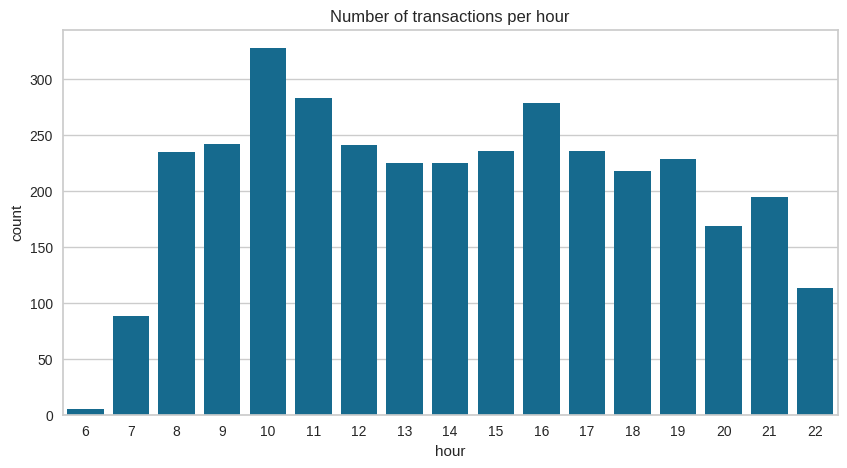

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=cluster_coffee_df, x="hour")
plt.title("Number of transactions per hour")
plt.show()

The chart shows the number of transactions depending on the hour.

A clear increase in sales was observed in the morning hours, with a peak around 10:00, indicating the highest customer activity during this period.

In the afternoon, sales remain at a relatively stable level, with a slight increase around 16:00, which may correspond to a second period of increased demand.

In the evening hours, a gradual decline in the number of transactions is visible.

This distribution indicates the presence of characteristic periods of customer activity throughout the day, which justifies the use of the hour variable in further clustering analysis.

This result suggests that purchase time is an important factor differentiating customer behavior.

### 3.2 Analysis of the relationship: coffee type vs time of day

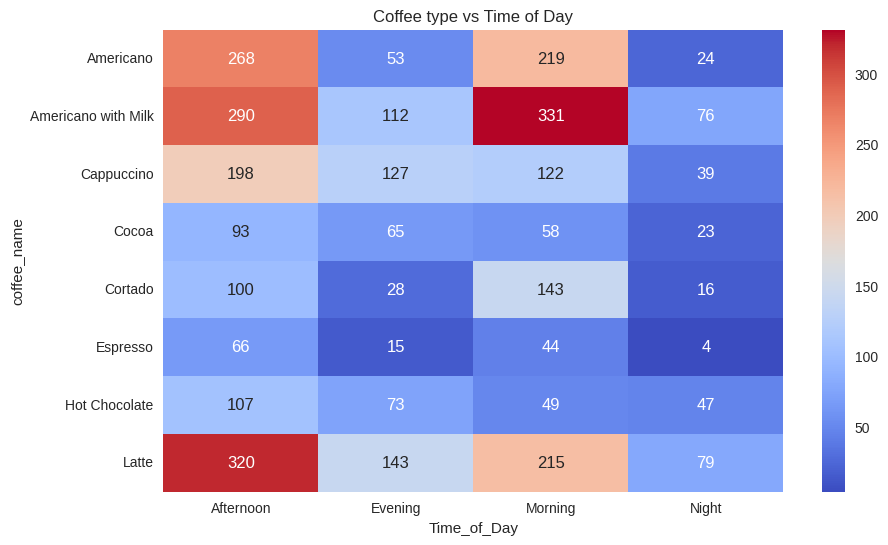

In [18]:
pivot = pd.crosstab(cluster_coffee_df["coffee_name"], cluster_coffee_df["Time_of_Day"])

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="coolwarm")
plt.title("Coffee type vs Time of Day")
plt.show()

The chart shows the relationship between coffee type and time of day, revealing clear differences in customer preferences.

It was observed that:

Americano and Americano with Milk are most frequently chosen in the morning and afternoon hours, indicating their popularity as “everyday” coffees consumed during the workday.
Americano with Milk reaches particularly high sales in the morning, suggesting a preference for milder, milk-based coffee variants at the start of the day.
Latte is characterized by high sales both in the morning and afternoon, and also maintains relatively high popularity at other times of the day, making it a versatile product.
Cappuccino and Hot Chocolate are more often chosen in the evening hours, which may indicate a preference for more “comfort” beverages outside of working hours.
Espresso and Cortado show lower sales levels compared to other beverages, without a clearly dominant time of day.

During nighttime hours, sales of all coffee types drop significantly, which is consistent with the natural cycle of customer activity.

The results suggest that time of day is an important factor influencing the choice of coffee type, which justifies the use of time-related variables in the clustering model.

### 3.3 Distribution of transactions by day of the week

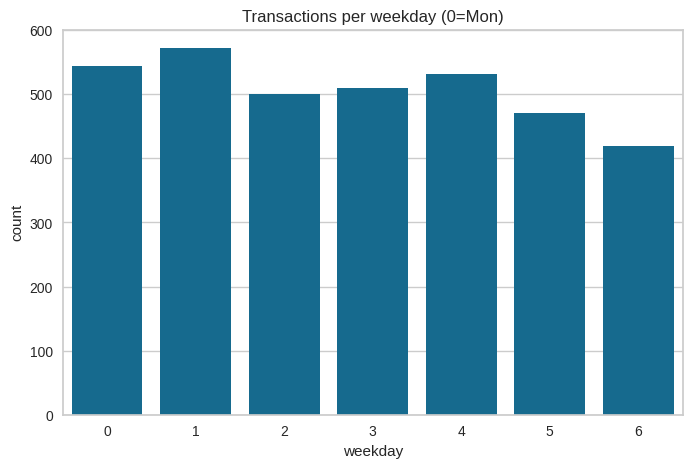

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=cluster_coffee_df, x="weekday")
plt.title("Transactions per weekday (0=Mon)")
plt.show()

The distribution of the number of transactions throughout the week is relatively uniform, indicating no strong relationship between the day of the week and customer activity.

🔥 Key conclusion

Therefore, the weekday variable has limited informational value and is not a key factor in further analysis.

### 3.4 Analysis of price distribution by coffee type

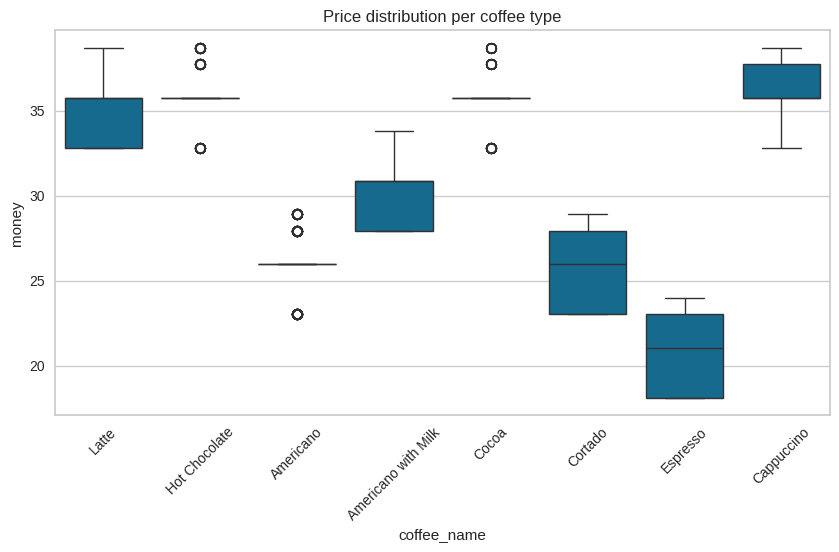

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=cluster_coffee_df, x="coffee_name", y="money")
plt.xticks(rotation=45)
plt.title("Price distribution per coffee type")
plt.show()

The chart shows the price distribution for individual coffee types.

Clear price differences between products were observed. Beverages such as Cappuccino and Latte reach the highest prices, while Espresso is characterized by the lowest price level.

The outliers visible in the chart are not the result of data errors, but stem from the presence of several discrete price levels for each product. This means that prices do not form a continuous distribution, but instead take on a limited number of values.

Therefore, the money variable was transformed into price levels (price_level), which allowed for a better representation of the data structure in further analysis.

In [21]:
cluster_coffee_df.groupby("coffee_name")["money"].nunique()

coffee_name
Americano              4
Americano with Milk    4
Cappuccino             4
Cocoa                  4
Cortado                4
Espresso               4
Hot Chocolate          4
Latte                  4
Name: money, dtype: int64

# 4. Data preparation for modeling

### 4.1 Time data processing

Due to the discrete nature of prices in the dataset, the money variable was transformed into price levels.

For each type of coffee, a price rank (price_level) was determined, representing the relative price level of a given product within its category (e.g., from the cheapest to the most expensive variant).

This approach allowed for a simplification of the data representation and better capture of relative price differences between products.

After the transformation, the money column was removed as unnecessary for further analysis.

In [22]:
cluster_coffee_df["price_level"] = cluster_coffee_df.groupby("coffee_name")["money"].rank(method="dense")
cluster_coffee_df["price_level"] = cluster_coffee_df["price_level"].astype(int)

In [23]:
cluster_coffee_df.drop(columns=["money"], inplace=True)

### 4.2 Selection of features for modeling

At the data preparation stage for modeling, columns that did not provide significant informational value or could negatively affect the model's performance were removed.

The removed variables included:

- redundant columns (e.g., Time_of_Day, datetime),
- variables with low informational value (weekday, month),
- columns not useful in the context of clustering (Date Time).

Only those features that best describe customer behavior were retained, namely purchase hour (hour) and price level (price_level).

Reducing the number of features helped to limit noise in the data and improved the quality and interpretability of the clustering model.

In [24]:
df_model = cluster_coffee_df.drop(columns=[
    "Time_of_Day",
    "Date Time",
    "datetime",
    "weekday",
    "month"
])

## 4.2.1 Model columns after transformations

In [25]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   coffee_name  3547 non-null   object
 1   hour         3547 non-null   int32 
 2   price_level  3547 non-null   int64 
dtypes: int32(1), int64(1), object(1)
memory usage: 69.4+ KB


## 4.3 Encoding of categorical variables

To enable the use of the coffee_name variable in the clustering model, one-hot encoding was applied to the "coffee_name" column.

This process involved transforming the categorical variable into a set of binary variables (0/1), representing individual types of coffee.

As a result, the data was adapted to the requirements of distance-based models such as KMeans, which operate exclusively on numerical values.

In [26]:
df_model = pd.get_dummies(df_model, columns=["coffee_name"])

## 5. Building the clustering model

### 5.1 Initial clustering model (including coffee type)

In [27]:
setup(data=df_model, normalize=True, session_id=123)

kmeans_model = create_model("kmeans")

,Description,Value
0,Session id,123
1,Original data shape,"(3547, 10)"
2,Transformed data shape,"(3547, 10)"
3,Numeric features,2
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,zscore


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3207,655.9937,1.4989,0,0,0


After encoding the coffee_name variable using one-hot encoding, an initial clustering attempt was performed using the KMeans algorithm.

Obtained results:

- Silhouette Score: 0.3207
- Calinski-Harabasz Index: 655.99
- Davies-Bouldin Index: 1.49

The silhouette coefficient value indicates a moderate clustering quality, suggesting partial overlap between clusters.

However, the analysis of the results showed that the model largely grouped the data based on coffee type (coffee_name), rather than customer behavior (such as time of day or price level).

This means that this variable had a dominant influence on the clustering process, limiting the ability to discover more complex purchasing patterns.

Therefore, it was decided to remove the coffee_name variable in further analysis in order to focus the model on more relevant behavioral features.

### 5.2 5.2 Selection of the number of clusters (elbow method)

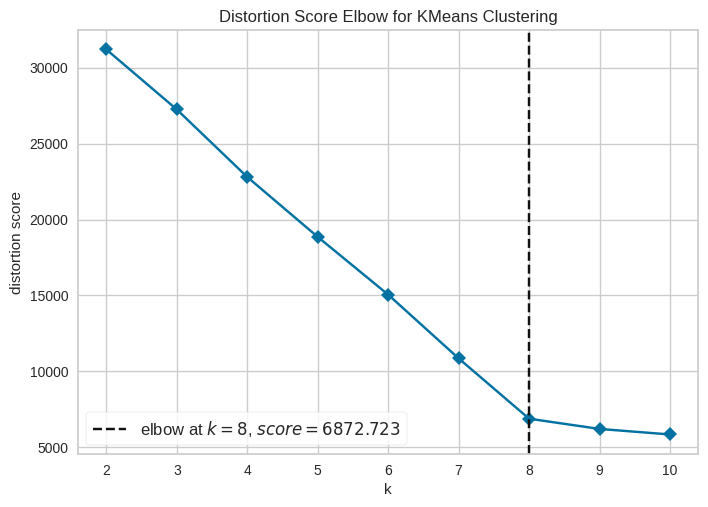

In [28]:
plot_model(kmeans_model, plot="elbow")

The elbow method indicates an optimal number of clusters around k=8. However, this result confirms the dominant influence of the coffee_name variable, causing the model to group data mainly by coffee type rather than customer behavior. Therefore, this result was considered misleading and used as a signal to modify the feature set.

# 6. Final clustering model

### 6.1 Model with 4 clusters
The final model was built using the previously defined setup, with the number of clusters manually set to 4.

In [29]:
kmeans_model_k4 = create_model("kmeans", num_clusters=4)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3207,655.9937,1.4989,0,0,0


The quality of the obtained clustering was evaluated using selected metrics:

- Silhouette Score: 0.4632
- Calinski-Harabasz Index: 3116.88
- Davies-Bouldin Index: 0.83

The obtained silhouette coefficient value indicates good clustering quality, with moderate overlap between clusters.

The low value of the Davies-Bouldin index confirms that the clusters are relatively compact and well separated.

The high value of the Calinski-Harabasz index further indicates a clear structure in the data.

These results suggest that the model effectively identifies meaningful groups of observations and can be used for further interpretation of customer behavior patterns.

## 6.2 Cluster characteristics

In [30]:
clustered = assign_model(kmeans_model_k4)
clustered.groupby("Cluster").mean()
# clustered["Cluster"].value_counts()

,hour,price_level,coffee_name_Americano,coffee_name_Americano with Milk,coffee_name_Cappuccino,coffee_name_Cocoa,coffee_name_Cortado,coffee_name_Espresso,coffee_name_Hot Chocolate,coffee_name_Latte
Cluster,,,,,,,,,,
Cluster 0,15.059727,2.105802,0.0,0.000000,0.276451,0.13595,0.0,0.000000,0.156997,0.430603
Cluster 1,13.186170,2.141844,1.0,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000
Cluster 2,12.651568,2.108014,0.0,0.000000,0.000000,0.00000,1.0,0.000000,0.000000,0.000000
Cluster 3,13.617271,2.040512,0.0,0.862473,0.000000,0.00000,0.0,0.137527,0.000000,0.000000


To interpret the clusters, the average values of features for each group were analyzed.

The obtained clusters differ primarily in the transaction hour, concentrating around specific time ranges (approximately 12–15). Differences in price level (price_level) are small, indicating that price was not the main factor differentiating the groups.

This means that the clustering reflects purchasing time patterns to a greater extent than customer price preferences.

## 7. Clustering on selected features (hour, price_level)

### 7.1 Simplified clustering model

To obtain more clear and interpretable results, a simplified clustering model was built using only two key features: transaction hour (hour) and price level (price_level).

This approach allowed the model to focus on the most important aspects of customer behavior, eliminating the influence of less relevant or dominant variables

In [31]:
df_model_h_pl = cluster_coffee_df[["hour", "price_level"]]

setup(df_model_h_pl, normalize=True, session_id=123)

kmeans_h_pl = create_model("kmeans", num_clusters=4)

clustered = assign_model(kmeans_h_pl)

,Description,Value
0,Session id,123
1,Original data shape,"(3547, 2)"
2,Transformed data shape,"(3547, 2)"
3,Numeric features,2
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,zscore


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4632,3116.8814,0.8281,0,0,0


For the simplified clustering model, the following results were obtained:

- Silhouette Score: 0.4632
- Calinski-Harabasz Index: 3116.88
- Davies-Bouldin Index: 0.83

Compared to previous approaches, the obtained metrics indicate an improvement in clustering quality. In particular, the higher silhouette coefficient suggests better separation of clusters.

This result confirms that limiting the number of features to key variables (hour, price_level) allowed for a more consistent and interpretable model.

In [32]:
clustered = assign_model(kmeans_h_pl)
clustered.groupby("Cluster").mean()

,hour,price_level
Cluster,,
Cluster 0,17.666182,1.758545
Cluster 1,11.545882,3.432941
Cluster 2,10.189655,1.658171
Cluster 3,18.220339,3.244552


The analysis of average feature values for each cluster allowed for the identification of a clear division of the data across two dimensions: purchase time and price level.

Based on this, the following groups were identified:

- Cluster 2 – purchases in the morning hours (~10), mainly involving cheaper products
- Cluster 1 – purchases in the late morning (~11–12), dominated by more expensive products
- Cluster 0 – purchases in the afternoon (~17), involving cheaper products
- Cluster 3 – purchases in the evening (~18), dominated by more expensive products

The results indicate a clear segmentation of customers not only by time of day, but also by product price level.

👉 customers tend to buy more expensive products later in the day

### 7.2 Cluster ranges

In [33]:

clustered.groupby("Cluster").agg({
    "hour": ["min", "max"],
    "price_level": ["min", "max"]
})

hour     price_level    
           min max         min max
Cluster                           
Cluster 0   14  22           1   2
Cluster 1    7  15           3   4
Cluster 2    6  14           1   2
Cluster 3   15  22           3   4

To better understand the structure of the clusters, the ranges of feature values in each group were analyzed.

The analysis showed that the clusters are not completely separated, and their ranges partially overlap. This results from the continuous nature of the data, particularly the hour variable, for which the boundaries between groups are fluid.

Despite this, it is possible to identify dominant patterns for each cluster, which confirms the validity of the obtained segmentation.

### 7.3 Distribution of products across clusters

In [34]:
clustered_with_names = clustered.join(cluster_coffee_df["coffee_name"])

clustered_with_names.groupby("Cluster")["coffee_name"].value_counts(normalize=True)

Cluster    coffee_name        
Cluster 0  Latte                  0.254545
           Americano with Milk    0.176727
           Cappuccino             0.142545
           Americano              0.134545
           Hot Chocolate          0.121455
           Cocoa                  0.101091
           Cortado                0.042182
           Espresso               0.026909
Cluster 1  Americano with Milk    0.240000
           Americano              0.200000
           Latte                  0.197647
           Cappuccino             0.143529
           Cortado                0.112941
           Hot Chocolate          0.047059
           Espresso               0.035294
           Cocoa                  0.023529
Cluster 2  Americano with Milk    0.275862
           Americano              0.190405
           Latte                  0.180660
           Cortado                0.111694
           Cappuccino             0.101199
           Cocoa                  0.057721
           Espresso    

Additionally, the distribution of coffee types across clusters was analyzed. No significant differences were observed, confirming that the clustering was mainly driven by time and price level.

# 8. Final conclusions

#### Goals:
1. Use of clustering to identify patterns of customer behavior.
2. Verification of whether the data contains characteristic groups of transactions related to purchase time and price level.
3. Identification of key sales hours and recurring purchasing patterns.

The conducted analysis made it possible to use clustering to identify patterns of customer behavior in coffee sales data.

The results showed that it is possible to distinguish characteristic groups of transactions that differ primarily in time of day and product price level. The clustering revealed a clear division into morning and afternoon-evening purchases, as well as segments associated with lower and higher price levels.

Key sales hours were also identified, with the highest customer activity in the morning hours and a secondary increase in the afternoon. At the same time, it was observed that higher-priced products are more often chosen later in the day.

The obtained results indicate that the main factors differentiating customer behavior are purchase time and price level, while other variables had a limited impact on the data structure.